1 : read in data

In [39]:
import pandas as pd

# training dataset 
df = pd.read_csv('../SAC105_Data/data.csv')

In [40]:
df

,Sn,Bi,In,Ti,T,E
0,92.9,3.0,2.5,0.1,64.60,20.85
1,92.7,3.0,2.5,0.3,62.59,23.69
2,92.5,3.0,2.5,0.5,72.05,22.84
3,91.9,3.0,3.5,0.1,66.60,19.79
4,91.7,3.0,3.5,0.3,70.29,21.60
5,91.5,3.0,3.5,0.5,68.33,15.95
6,91.9,4.0,2.5,0.1,77.65,16.44
7,91.7,4.0,2.5,0.3,80.49,16.64
8,91.5,4.0,2.5,0.5,81.03,15.66
9,90.9,4.0,3.5,0.1,78.59,18.44


In [41]:
# Visual_samples dataset

vs = pd.read_csv('../SAC105_Data/Visual_samples.csv')

In [42]:
vs

,Sn,Bi,In,Ti
0,95.4,1.5,1.5,0.1
1,95.3,1.5,1.5,0.2
2,95.2,1.5,1.5,0.3
3,95.1,1.5,1.5,0.4
4,95.0,1.5,1.5,0.5
...,...,...,...,...
11762,87.2,5.5,5.5,0.3
11763,87.1,5.5,5.5,0.4
11764,87.0,5.5,5.5,0.5
11765,86.9,5.5,5.5,0.6


2 : train GPR model

For multi-target optimization, we use multi-target Gaussian Process Regression (GPR) to account for the joint relationships

In [43]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut
import warnings
warnings.filterwarnings("ignore") 

X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

loo = LeaveOneOut()
y_pred_list = []

# define the model 
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-5, 1e5))  + C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-5, 1e5)) 
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30)

# perform LOOCV
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = np.array(y)[train_index], np.array(y)[test_index]

    # Fit the model
    gpr.fit(X_train, y_train)

    # Predict for the test instance
    y_pred_list.append(gpr.predict(X_test))

# Convert predictions to array
y_pred = np.vstack(y_pred_list)  # Stack predictions to get full array

# Calculate R2 score
r2 = r2_score(y, y_pred, multioutput='uniform_average')
print(r2)

0.781811090759919


The model performs reasonably well. For a specific candidate dataset, we can evaluate its property performance.

In [33]:
candidate_datum = np.array(([92, 1, 3, 4])).reshape(1, -1) 

model = gpr.fit(X, y)
y_pred, y_cov = model.predict(candidate_datum, return_cov=True)

print("Predicted value:", y_pred)
print("Prediction covariance matrix:", y_cov)

Predicted value: [[45.03057995 14.27363104]]
Prediction covariance matrix: [[[427.89712743 427.89712743]]]


After deriving the distribution, we can sample specific data points from the posterior.

In [23]:
y_pred[0]

array([63.56830048, 24.29029876])

In [25]:
y_cov[0][0]

array([110.16074485, 110.16074485])

In [73]:
from scipy.stats import multivariate_normal

y_sample = multivariate_normal.rvs(mean=y_pred[0], cov=np.diag(y_cov[0][0]))
y_sample

array([85.2781775 , 22.42503842])

In [74]:
# use MultiBgolearn to calculate the HV
from MultiBgolearn.utility import funs

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)
current_lebesgue_measure = funs.calculate_lebesgue_measure(pareto_front,True)

# add the sampled datum into the dataset
extended_y = np.vstack([y, y_sample])
new_pareto_front = funs.get_pareto_front(extended_y,True)
new_lebesgue_measure = funs.calculate_lebesgue_measure(new_pareto_front,True)


max(new_lebesgue_measure - current_lebesgue_measure,0)

40.97065453324882

With this specific value, we can calculate the improvement in hypervolume (HV).

We sample \( N \) points from the posterior and calculate \( N \) HV values. The mean of these values represents the Expected Hypervolume Improvement (EHVI).

By iterating over all candidates, we derive the EHVI for each and select the one with the maximum value.

### The above process can be efficiently implemented using MultiBgolearn with just a few concise lines of code. Here's an example of how it can be done

pip install MultiBgolearn

In [8]:
from MultiBgolearn import bgo

# Define your dataset and virtual space paths
dataset_path = '../SAC105_Data/data.csv'
VS_path = '../SAC105_Data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='EHVI', 
    assign_model='GaussianProcess', 
    bootstrap=20
)

The next recommended data by method 'EHVI' is: [94.5  1.8  1.8  0.4]


In [9]:
VS_recommended

array([94.5,  1.8,  1.8,  0.4])

In [11]:
improvements[index]

0.34952248493784427

We can evaluate the properties of the recommended data using the experimental simulator.

In [33]:
import joblib


# Load the trained models
svr_model_1 = joblib.load('../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')

Predicted value for target 1: 78.48522918173721
Predicted value for target 2: 20.681551044693478


C:\Users\binja\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
C:\Users\binja\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(


In [34]:
# use MultiBgolearn to calculate the HV
from MultiBgolearn.utility import funs
# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

In [35]:
pareto_front

array([[ 80.49,  16.64],
       [ 78.59,  18.44],
       [ 87.58,  16.29],
       [ 95.07,  15.05],
       [110.56,  13.69],
       [113.44,  12.64],
       [ 62.67,  26.36],
       [ 78.49,  22.38],
       [ 73.94,  24.37]])

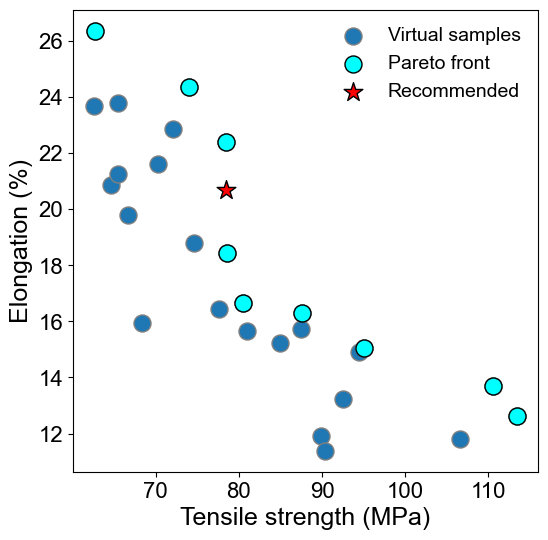

In [38]:
import matplotlib.pyplot as plt

# Set global font to Arial
plt.rc('font', family='Arial')

fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Virtual samples')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)


# Save the plot (uncomment if needed)
plt.savefig('ParetoF_1.png', dpi=800)
plt.savefig('ParetoF_1.svg', dpi=800)

plt.show()


### ! sorry for the typo, The 'virtual samples' should be replace with 'training data' in fig


The effect is positive; the recommended data extends the Pareto front.

Add the infill data to the original dataset, then derive the new training data.


In [50]:
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])

In [51]:
new_row

array([94.5       ,  1.8       ,  1.8       ,  0.4       , 78.48522918,
       20.68155104])

In [52]:
df = pd.read_csv('../SAC105_Data/data.csv')

# Append the new row to the DataFrame
df.loc[len(df)] = new_row

# Save the updated DataFrame to a new CSV file
df.to_csv('./new_datasets/first.csv', index=False)

### the second iteration

The next recommended data by method 'EHVI' is: [88.1  5.1  5.2  0.1]
the recommended data is : [88.1  5.1  5.2  0.1]
the HV is : 0.20422856669020772
Predicted value for target 1: 102.90800143704449
Predicted value for target 2: 12.826854763914554


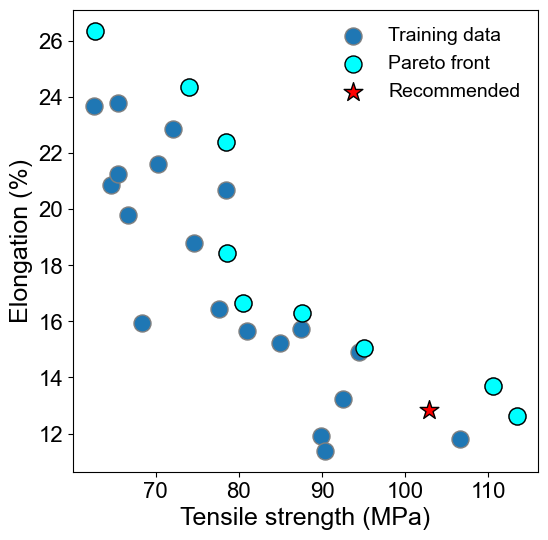

In [64]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

# multi-target BGO
#################################################
# Define your dataset and virtual space paths
dataset_path = './new_datasets/first.csv'
VS_path = '../SAC105_Data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='EHVI', 
    assign_model='GaussianProcess', 
    bootstrap=20
)

print('the recommended data is :',VS_recommended)
print('the HV is :', improvements[index])
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_2.png', dpi=800)
plt.savefig('ParetoF_2.svg', dpi=800)
plt.show()
#################################################

In [65]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./new_datasets/second.csv', index=False)

### the third iteration

The next recommended data by method 'EHVI' is: [95.   1.8  1.6  0.1]
the recommended data is : [95.   1.8  1.6  0.1]
the HV is : 0.15834223219643367
Predicted value for target 1: 81.15857159119685
Predicted value for target 2: 19.106377827021998


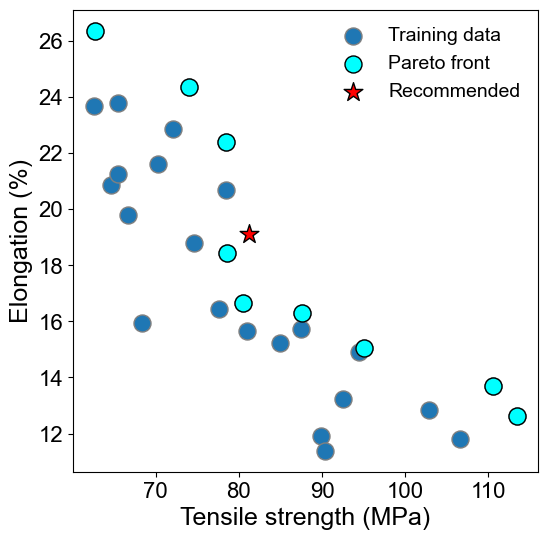

In [66]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

# multi-target BGO
#################################################
# Define your dataset and virtual space paths
dataset_path = './new_datasets/second.csv'
VS_path = '../SAC105_Data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='EHVI', 
    assign_model='GaussianProcess', 
    bootstrap=20
)

print('the recommended data is :',VS_recommended)
print('the HV is :', improvements[index])
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_3.png', dpi=800)
plt.savefig('ParetoF_3.svg', dpi=800)
plt.show()
#################################################

In [67]:
# update dataset 
new_row = np.concatenate([new_features[0], [prediction_1[0]], [prediction_2[0]]])
# Append the new row to the DataFrame
df.loc[len(df)] = new_row
# Save the updated DataFrame to a new CSV file
df.to_csv('./new_datasets/third.csv', index=False)

### the fourth iteration

The next recommended data by method 'EHVI' is: [87.6  5.5  5.3  0.1]
the recommended data is : [87.6  5.5  5.3  0.1]
the HV is : 0.18706323506070682
Predicted value for target 1: 108.81119908089877
Predicted value for target 2: 12.82780074619541


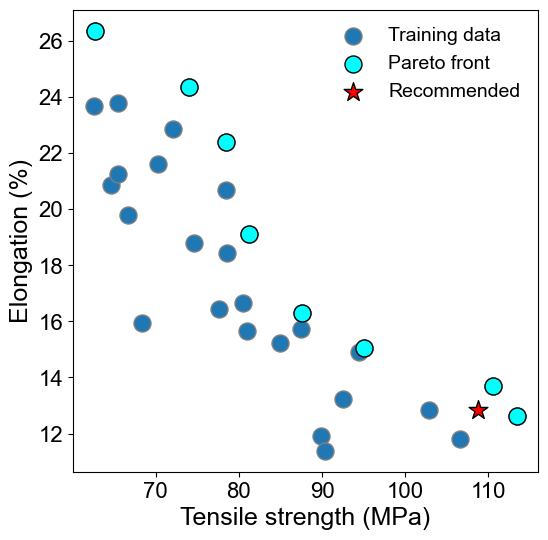

In [68]:
from MultiBgolearn import bgo
import numpy as np
from MultiBgolearn.utility import funs
import matplotlib.pyplot as plt
import joblib

# multi-target BGO
#################################################
# Define your dataset and virtual space paths
dataset_path = './new_datasets/third.csv'
VS_path = '../SAC105_Data/Visual_samples.csv'

# Set the number of objectives (e.g., 3 for three-objective optimization)
object_num = 2

# Apply Multi-Objective Bayesian Global Optimization
VS_recommended, improvements, index = bgo.fit(
    dataset_path, 
    VS_path, 
    object_num, 
    max_search=True, 
    method='EHVI', 
    assign_model='GaussianProcess', 
    bootstrap=20
)

print('the recommended data is :',VS_recommended)
print('the HV is :', improvements[index])
#################################################


# evl the properties
#################################################
# Load the trained models
svr_model_1 = joblib.load('../SAC105_Data/svm_model_target1.joblib')
svr_model_2 = joblib.load('../SAC105_Data/svm_model_target2.joblib')

# Input new features (replace with actual feature values)
new_features = VS_recommended.reshape(1, -1) 

# Make predictions for both targets
prediction_1 = svr_model_1.predict(new_features)
prediction_2 = svr_model_2.predict(new_features)

# Output the predicted values
print(f'Predicted value for target 1: {prediction_1[0]}')
print(f'Predicted value for target 2: {prediction_2[0]}')
#################################################


# plot
#################################################
df = pd.read_csv(dataset_path)
X = np.array(df.iloc[:, :-2])
y = np.array(df.iloc[:, -2:])

# original pareto_front and lebesgue_measure 
pareto_front = funs.get_pareto_front(y,True)

# Set global font to Arial
plt.rc('font', family='Arial')
fig = plt.figure(figsize=[6, 6])  # Slightly larger figure for clarity
plt.scatter(y[:, 0], y[:, 1], marker='o', edgecolor='gray', s=150, label='Training data')
plt.scatter(pareto_front[:, 0], pareto_front[:, 1], marker='o', c='cyan', s=150, edgecolor='k', label='Pareto front')
plt.scatter(prediction_1[0], prediction_2[0], marker='*', c='red', s=200, edgecolor='k', label='Recommended')

# Add axis labels with larger font size
plt.xlabel('Tensile strength (MPa)', fontsize=18)
plt.ylabel('Elongation (%)', fontsize=18)

# Customize legend
plt.legend(fontsize=14, loc='upper right', frameon=False)  # Frame removed for cleaner look

# Adjust tick parameters
plt.tick_params(labelsize=16)

# Save the plot (uncomment if needed)
plt.savefig('ParetoF_4.png', dpi=800)
plt.savefig('ParetoF_4.svg', dpi=800)
plt.show()
#################################################

# Stopping iteration here